# Datathon Passos Mágicos — Análise Exploratória

## 1. Introdução

Este notebook tem como objetivo realizar a exploração inicial da base de dados da Associação Passos Mágicos disponibilizada para o Datathon da Pós-Tech.

A análise busca compreender a estrutura dos dados, identificar problemas de qualidade e avaliar a disponibilidade das informações necessárias para as etapas posteriores do projeto.

Nesta etapa não serão realizadas transformações definitivas na base. Problemas encontrados serão documentados para tratamento posterior.

### Objetivos

- Identificar as planilhas disponíveis no arquivo original;
- Analisar dimensões e estrutura dos datasets;
- Verificar os tipos das variáveis;
- Identificar valores ausentes;
- Identificar registros duplicados;
- Avaliar a consistência das principais variáveis;
- Comparar a estrutura entre os anos;
- Verificar a presença dos alunos ao longo dos anos;
- Explorar inicialmente os indicadores educacionais;
- Identificar problemas que deverão ser tratados antes da análise e da modelagem preditiva.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Carregamento dos dados

A base original está armazenada em um arquivo Excel contendo diferentes abas correspondentes aos anos analisados.

Antes de carregar individualmente cada período, serão identificadas as planilhas existentes no arquivo.

In [2]:
from pathlib import Path

NOME_ARQUIVO = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"
possiveis_raizes = [Path.cwd().resolve(), Path.cwd().resolve().parent]

DATA_PATH = None
for raiz in possiveis_raizes:
    candidato = raiz / "data" / "raw" / NOME_ARQUIVO
    if candidato.exists():
        DATA_PATH = candidato
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Arquivo não encontrado em data/raw. Verifique a estrutura do projeto."
    )

print(f"Arquivo encontrado: {DATA_PATH}")

Arquivo encontrado: C:\Users\chopa\OneDrive\Área de Trabalho\DATATHON 5\data\raw\BASE DE DADOS PEDE 2024 - DATATHON.xlsx


In [3]:
excel_file = pd.ExcelFile(DATA_PATH)

print("Abas disponíveis:")
for sheet in excel_file.sheet_names:
    print(f"- {sheet}")

Abas disponíveis:
- PEDE2022
- PEDE2023
- PEDE2024


### Carregamento das bases anuais

Após a identificação das abas disponíveis, cada período será carregado separadamente.

Neste momento, os datasets serão mantidos em sua estrutura original. A padronização entre os anos será realizada posteriormente no notebook de tratamento.

In [4]:
df_2022 = pd.read_excel(DATA_PATH, sheet_name="PEDE2022")
df_2023 = pd.read_excel(DATA_PATH, sheet_name="PEDE2023")
df_2024 = pd.read_excel(DATA_PATH, sheet_name="PEDE2024")

print(f"2022: {df_2022.shape[0]:,} linhas x {df_2022.shape[1]} colunas")
print(f"2023: {df_2023.shape[0]:,} linhas x {df_2023.shape[1]} colunas")
print(f"2024: {df_2024.shape[0]:,} linhas x {df_2024.shape[1]} colunas")

bases = {2022: df_2022, 2023: df_2023, 2024: df_2024}


2022: 860 linhas x 42 colunas
2023: 1,014 linhas x 48 colunas
2024: 1,156 linhas x 50 colunas


## 3. Estrutura dos datasets

Nesta etapa será analisada a estrutura básica de cada período, incluindo quantidade de registros, quantidade de variáveis e uma amostra dos dados.

Essa análise permite identificar diferenças estruturais entre os anos antes de qualquer tentativa de consolidação.

In [5]:
for ano, df in {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}.items():
    print(f"\n{'=' * 30} {ano} {'=' * 30}")
    display(df.head())


============================== 2022 ==============================


,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Matem,Portug,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753,18,10,4,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.3,4.1,5.6,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Melhorar: Integrar-se mais aos Princípios Passos Mágicos.
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469,8,3,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.8,5.2,6.3,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Melhorar: Integrar-se mais aos Princípios Passos Mágicos.
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629,13,6,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.0,7.9,5.6,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Destaque: A sua boa integração aos Princípios Passos Mágicos.
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.951,731,15,7,4,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.8,4.5,5.6,Requer avaliação,5.0,2.8,3.5,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Melhorar: Integrar-se mais aos Princípios Passos Mágicos.
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ametista,7.427,344,6,2,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.9,8.6,5.6,Requer avaliação,5.2,7.0,2.9,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliações.,Melhorar: Integrar-se mais aos Princípios Passos Mágicos.



============================== 2023 ==============================


,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,9.5,10.0,8.13,8.4375,NaN,9.6,9.8,9.4,NaN,NaN,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,8.5,9.1,8.14,7.5000,NaN,8.9,8.5,9.2,NaN,NaN,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,0.0,7.6,3.14,5.9375,NaN,6.3,7.0,5.5,NaN,NaN,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
3,RA-864,ALFA,7.03400,Ametista,ALFA A - G0/G1,Aluno-864,2015-12-03 00:00:00,1900-01-08 00:00:00,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,0.0,7.6,8.14,7.5000,NaN,6.3,7.0,5.5,NaN,NaN,NaN,8.500,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
4,RA-865,ALFA,8.15520,Topázio,ALFA A - G0/G1,Aluno-865,11/13/2014,8,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,8.5,8.7,7.52,7.5000,NaN,7.4,7.3,7.5,NaN,NaN,NaN,7.915,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN



============================== 2024 ==============================


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Avaliador4,Avaliador5,Avaliador6,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,8.666667,6.26,5.625,NaN,8.0,10.0,6.0,NaN,NaN,NaN,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,9.333333,3.76,7.500,NaN,8.0,10.0,6.0,NaN,NaN,NaN,7.050000,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,9.083333,3.76,7.500,NaN,8.0,10.0,6.0,NaN,NaN,NaN,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,Pública,NaN,NaN,NaN,Topázio,NaN,8.63895,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,8.002,9.750000,3.76,6.875,NaN,7.0,8.0,6.0,NaN,NaN,NaN,7.213333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,9.002,4.166667,3.76,5.000,NaN,7.5,8.0,7.0,NaN,NaN,NaN,4.173333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando


In [6]:
for ano, df in {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}.items():
    
    print(f"\nCOLUNAS DE {ano}")
    print("-" * 60)
    
    for i, coluna in enumerate(df.columns, start=1):
        print(f"{i:02d}. {coluna}")


COLUNAS DE 2022
------------------------------------------------------------
01. RA
02. Fase
03. Turma
04. Nome
05. Ano nasc
06. Idade 22
07. Gênero
08. Ano ingresso
09. Instituição de ensino
10. Pedra 20
11. Pedra 21
12. Pedra 22
13. INDE 22
14. Cg
15. Cf
16. Ct
17. Nº Av
18. Avaliador1
19. Rec Av1
20. Avaliador2
21. Rec Av2
22. Avaliador3
23. Rec Av3
24. Avaliador4
25. Rec Av4
26. IAA
27. IEG
28. IPS
29. Rec Psicologia
30. IDA
31. Matem
32. Portug
33. Inglês
34. Indicado
35. Atingiu PV
36. IPV
37. IAN
38. Fase ideal
39. Defas
40. Destaque IEG
41. Destaque IDA
42. Destaque IPV

COLUNAS DE 2023
------------------------------------------------------------
01. RA
02. Fase
03. INDE 2023
04. Pedra 2023
05. Turma
06. Nome Anonimizado
07. Data de Nasc
08. Idade
09. Gênero
10. Ano ingresso
11. Instituição de ensino
12. Pedra 20
13. Pedra 21
14. Pedra 22
15. Pedra 23
16. INDE 22
17. INDE 23
18. Cg
19. Cf
20. Ct
21. Nº Av
22. Avaliador1
23. Rec Av1
24. Avaliador2
25. Rec Av2
26. Avaliador3
27.

## 4. Tipos das variáveis

A verificação dos tipos de dados permite identificar possíveis inconsistências de importação.

Variáveis numéricas armazenadas como texto ou data, por exemplo, podem comprometer cálculos estatísticos, visualizações e posteriormente o treinamento dos modelos de Machine Learning.

In [7]:
for ano, df in {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}.items():
    
    print(f"\nTIPOS DE DADOS — {ano}")
    print("-" * 60)
    
    display(
        df.dtypes
        .astype(str)
        .value_counts()
        .rename("Quantidade")
        .to_frame()
    )


TIPOS DE DADOS — 2022
------------------------------------------------------------


,Quantidade
object,23
float64,10
int64,9



TIPOS DE DADOS — 2023
------------------------------------------------------------


,Quantidade
float64,29
object,17
int64,2



TIPOS DE DADOS — 2024
------------------------------------------------------------


,Quantidade
float64,23
object,22
int64,4
datetime64[ns],1


In [8]:
tipos = []

for ano, df in {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}.items():
    
    for coluna in df.columns:
        tipos.append({
            "Ano": ano,
            "Coluna": coluna,
            "Tipo": str(df[coluna].dtype)
        })

df_tipos = pd.DataFrame(tipos)

display(df_tipos)

,Ano,Coluna,Tipo
0,2022,RA,object
1,2022,Fase,int64
2,2022,Turma,object
3,2022,Nome,object
4,2022,Ano nasc,int64
...,...,...,...
135,2024,Destaque IDA,float64
136,2024,Destaque IPV,float64
137,2024,Escola,object
138,2024,Ativo/ Inativo,object


### Inconsistências de tipo identificadas

Dois pontos precisam ser tratados posteriormente:

- Em **2023**, a coluna `Idade` mistura inteiros com datas do ano de 1900;
- Em **2024**, `INDE 2024` contém números, valores nulos e a string `INCLUIR`.

A célula abaixo quantifica esses casos sem alterar a base original.

In [9]:

print("Tipos encontrados em Idade — 2023:")
display(df_2023["Idade"].map(lambda x: type(x).__name__).value_counts().to_frame("Quantidade"))

inde_2024_num = pd.to_numeric(df_2024["INDE 2024"], errors="coerce")
nao_numerico = inde_2024_num.isna() & df_2024["INDE 2024"].notna()

print(f"INDE 2024 numéricos válidos: {inde_2024_num.notna().sum()}")
print(f"INDE 2024 nulos: {df_2024['INDE 2024'].isna().sum()}")
print(f"INDE 2024 textuais/não numéricos: {nao_numerico.sum()}")
display(df_2024.loc[nao_numerico, "INDE 2024"].value_counts().to_frame("Quantidade"))


Tipos encontrados em Idade — 2023:


,Quantidade
Idade,
int,615
datetime,399


INDE 2024 numéricos válidos: 1054
INDE 2024 nulos: 64
INDE 2024 textuais/não numéricos: 38


,Quantidade
INDE 2024,
INCLUIR,38


## 5. Análise de valores ausentes

Valores ausentes podem ocorrer por diferentes motivos, como ausência de avaliação, indisponibilidade de determinado indicador em um período ou problemas de preenchimento.

Antes de definir qualquer estratégia de tratamento, será analisada a quantidade e a proporção de valores ausentes em cada variável.

In [10]:
def analisar_nulos(df):
    nulos = df.isna().sum()
    percentual = (nulos / len(df) * 100).round(2)

    resultado = pd.DataFrame({
        "Nulos": nulos,
        "Percentual (%)": percentual
    })

    return resultado[resultado["Nulos"] > 0].sort_values(
        "Percentual (%)",
        ascending=False
    )

In [11]:
print("2022")
display(analisar_nulos(df_2022))

print("2023")
display(analisar_nulos(df_2023))

print("2024")
display(analisar_nulos(df_2024))

2022


,Nulos,Percentual (%)
Inglês,577,67.09
Rec Av4,564,65.58
Avaliador4,550,63.95
Pedra 20,537,62.44
Pedra 21,398,46.28
Avaliador3,326,37.91
Matem,2,0.23
Portug,2,0.23


2023


,Nulos,Percentual (%)
Cg,1014,100.00
Cf,1014,100.00
INDE 23,1014,100.00
Pedra 23,1014,100.00
Rec Av3,1014,100.00
Atingiu PV,1014,100.00
Indicado,1014,100.00
Destaque IEG,1014,100.00
Ct,1014,100.00
Rec Av4,1014,100.00


2024


,Nulos,Percentual (%)
Rec Av1,1156,100.00
Cf,1156,100.00
Cg,1156,100.00
Destaque IPV,1156,100.00
Destaque IEG,1156,100.00
Indicado,1156,100.00
Ct,1156,100.00
Rec Av2,1156,100.00
Atingiu PV,1156,100.00
Destaque IDA,1156,100.00


## 6. Verificação de duplicidades

A presença de registros duplicados pode distorcer indicadores agregados e introduzir viés nas análises.

Serão verificadas tanto duplicidades completas quanto possíveis repetições do identificador do aluno dentro do mesmo período.

In [12]:
for ano, df in {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}.items():
    
    duplicados = df.duplicated().sum()
    
    print(f"{ano}: {duplicados} registros completamente duplicados")

2022: 0 registros completamente duplicados
2023: 0 registros completamente duplicados
2024: 0 registros completamente duplicados


## 7. Identificação e acompanhamento dos alunos

Para realizar análises longitudinais é necessário identificar um campo capaz de representar o mesmo aluno em diferentes períodos.

A variável `RA` será avaliada como possível identificador individual. Também será verificada a existência de duplicidades desse identificador dentro de cada ano.

In [13]:
for ano, df in {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}.items():
    
    print(f"\n{ano}")
    print(f"Registros: {len(df)}")
    print(f"RAs únicos: {df['RA'].nunique()}")
    print(f"RAs nulos: {df['RA'].isna().sum()}")
    print(f"RAs duplicados: {df['RA'].duplicated().sum()}")


2022
Registros: 860
RAs únicos: 860
RAs nulos: 0
RAs duplicados: 0

2023
Registros: 1014
RAs únicos: 1014
RAs nulos: 0
RAs duplicados: 0

2024
Registros: 1156
RAs únicos: 1156
RAs nulos: 0
RAs duplicados: 0


## 8. Presença dos alunos ao longo dos anos

Uma das possibilidades mais relevantes para o projeto é acompanhar a evolução de um mesmo aluno ao longo do tempo.

Por isso, será analisada a interseção dos identificadores entre 2022, 2023 e 2024, permitindo avaliar o potencial da base para análises longitudinais e para a construção de um modelo preditivo temporal.

In [14]:
ra_2022 = set(df_2022["RA"].dropna())
ra_2023 = set(df_2023["RA"].dropna())
ra_2024 = set(df_2024["RA"].dropna())

print(f"Alunos em 2022: {len(ra_2022)}")
print(f"Alunos em 2023: {len(ra_2023)}")
print(f"Alunos em 2024: {len(ra_2024)}")

print()
print(f"Presentes em 2022 e 2023: {len(ra_2022 & ra_2023)}")
print(f"Presentes em 2023 e 2024: {len(ra_2023 & ra_2024)}")
print(f"Presentes nos três anos: {len(ra_2022 & ra_2023 & ra_2024)}")

Alunos em 2022: 860
Alunos em 2023: 1014
Alunos em 2024: 1156

Presentes em 2022 e 2023: 600
Presentes em 2023 e 2024: 765
Presentes nos três anos: 468


## 9. Estatísticas descritivas

A análise descritiva fornece uma visão inicial da distribuição das variáveis numéricas, permitindo identificar amplitude, tendência central, dispersão e possíveis valores atípicos.

Neste momento, os resultados serão utilizados apenas para diagnóstico. Valores aparentemente inconsistentes serão investigados antes de qualquer remoção ou correção.

In [15]:
for ano, df in {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}.items():
    
    print(f"\nESTATÍSTICAS DESCRITIVAS — {ano}")
    display(df.describe(include="number").T)


ESTATÍSTICAS DESCRITIVAS — 2022


,count,mean,std,min,25%,50%,75%,max
Fase,860.0,2.098837,1.788789,0.000,1.0000,2.000,3.00000,7.000
Ano nasc,860.0,2009.861628,2.771998,2001.000,2008.0000,2010.000,2012.00000,2015.000
Idade 22,860.0,12.138372,2.771998,7.000,10.0000,12.000,14.00000,21.000
Ano ingresso,860.0,2020.496512,1.790217,2016.000,2019.0000,2021.000,2022.00000,2022.000
INDE 22,860.0,7.036176,1.017773,3.032,6.4855,7.197,7.75125,9.442
Cg,860.0,430.516279,248.432761,1.000,215.7500,430.500,645.25000,862.000
Cf,860.0,75.519767,52.312670,1.000,30.0000,67.000,118.00000,192.000
Ct,860.0,6.598837,3.975858,1.000,3.0000,6.000,9.00000,18.000
Nº Av,860.0,3.054651,0.775371,2.000,2.0000,3.000,4.00000,4.000
IAA,860.0,8.274419,2.064935,0.000,7.9000,8.800,9.50000,10.000



ESTATÍSTICAS DESCRITIVAS — 2023


,count,mean,std,min,25%,50%,75%,max
INDE 2023,931.0,7.342309,0.901757,3.745542,6.724150,7.408033,7.996083,9.371200
Ano ingresso,1014.0,2021.378698,1.873750,2016.000000,2021.000000,2022.000000,2023.000000,2023.000000
Pedra 23,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INDE 22,600.0,7.262788,0.895774,3.700000,6.740250,7.402500,7.903500,9.442000
INDE 23,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cg,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cf,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ct,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nº Av,938.0,3.109808,0.768712,2.000000,3.000000,3.000000,4.000000,4.000000
Rec Av1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



ESTATÍSTICAS DESCRITIVAS — 2024


,count,mean,std,min,25%,50%,75%,max
Idade,1156.0,12.987889,3.584699,7.000000,10.000000,12.000000,15.000000,27.000000
Ano ingresso,1156.0,2022.519896,1.204804,2021.000000,2021.000000,2023.000000,2024.000000,2024.000000
INDE 22,472.0,7.368276,0.861821,3.031806,6.890881,7.475431,7.981160,9.441522
INDE 23,690.0,7.455472,0.850390,4.406458,6.862402,7.559046,8.048758,9.371200
Cg,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cf,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ct,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nº Av,1156.0,2.951557,1.397985,0.000000,2.000000,3.000000,4.000000,6.000000
Rec Av1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rec Av2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Exploração inicial dos indicadores educacionais

Os principais indicadores analisados no Datathon representam diferentes dimensões do desenvolvimento dos alunos:

- **IAN:** Indicador de Adequação ao Nível;
- **IDA:** Indicador de Aprendizagem;
- **IEG:** Indicador de Engajamento;
- **IAA:** Indicador de Autoavaliação;
- **IPS:** Indicador Psicossocial;
- **IPP:** Indicador Psicopedagógico;
- **IPV:** Indicador de Ponto de Virada;
- **INDE:** Índice de Desenvolvimento Educacional.

Nesta etapa será analisada inicialmente a disponibilidade e distribuição desses indicadores.

In [16]:
indicadores = ["INDE", "IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV"]

mapa_indicadores = {
    2022: {"INDE": "INDE 22", "IAN": "IAN", "IDA": "IDA", "IEG": "IEG", "IAA": "IAA", "IPS": "IPS", "IPP": None, "IPV": "IPV"},
    2023: {"INDE": "INDE 2023", "IAN": "IAN", "IDA": "IDA", "IEG": "IEG", "IAA": "IAA", "IPS": "IPS", "IPP": "IPP", "IPV": "IPV"},
    2024: {"INDE": "INDE 2024", "IAN": "IAN", "IDA": "IDA", "IEG": "IEG", "IAA": "IAA", "IPS": "IPS", "IPP": "IPP", "IPV": "IPV"},
}

mapa_pedra = {2022: "Pedra 22", 2023: "Pedra 2023", 2024: "Pedra 2024"}
mapa_defasagem = {2022: "Defas", 2023: "Defasagem", 2024: "Defasagem"}

disponibilidade = []
for ano, df in {2022: df_2022, 2023: df_2023, 2024: df_2024}.items():
    for indicador, coluna in mapa_indicadores[ano].items():
        disponibilidade.append({
            "Ano": ano,
            "Indicador": indicador,
            "Disponível": coluna is not None and coluna in df.columns
        })

df_disponibilidade = pd.DataFrame(disponibilidade)
display(df_disponibilidade.pivot(index="Indicador", columns="Ano", values="Disponível"))

Ano,2022,2023,2024
Indicador,,,
IAA,True,True,True
IAN,True,True,True
IDA,True,True,True
IEG,True,True,True
INDE,True,True,True
IPP,False,True,True
IPS,True,True,True
IPV,True,True,True


In [17]:
for ano, df in {2022: df_2022, 2023: df_2023, 2024: df_2024}.items():
    dados = {}
    for indicador, coluna in mapa_indicadores[ano].items():
        if coluna is not None and coluna in df.columns:
            dados[indicador] = pd.to_numeric(df[coluna], errors="coerce")

    print(f"\nINDICADORES — {ano}")
    display(pd.DataFrame(dados).describe().T.round(2))


INDICADORES — 2022


,count,mean,std,min,25%,50%,75%,max
INDE,860.0,7.04,1.02,3.03,6.49,7.20,7.75,9.44
IAN,860.0,6.42,2.39,2.50,5.00,5.00,10.00,10.00
IDA,860.0,6.09,2.05,0.00,4.80,6.30,7.60,9.90
IEG,860.0,7.89,1.64,0.00,7.00,8.30,9.10,10.00
IAA,860.0,8.27,2.06,0.00,7.90,8.80,9.50,10.00
IPS,860.0,6.90,1.07,2.50,6.30,7.50,7.50,10.00
IPV,860.0,7.25,1.09,2.50,6.72,7.33,7.92,10.00



INDICADORES — 2023


,count,mean,std,min,25%,50%,75%,max
INDE,931.0,7.34,0.90,3.75,6.72,7.41,8.00,9.37
IAN,1014.0,7.24,2.54,2.50,5.00,5.00,10.00,10.00
IDA,937.0,6.66,1.60,0.00,5.70,6.80,7.90,10.00
IEG,938.0,8.70,1.08,3.70,8.10,9.00,9.50,10.00
IAA,951.0,6.90,3.59,0.00,6.70,8.50,9.20,10.00
IPS,945.0,5.12,2.09,2.52,2.52,5.00,7.52,10.00
IPP,938.0,7.56,0.98,3.75,7.08,7.66,8.12,9.79
IPV,938.0,8.03,0.95,3.32,7.46,8.04,8.67,10.01



INDICADORES — 2024


,count,mean,std,min,25%,50%,75%,max
INDE,1054.0,7.40,1.01,3.79,6.77,7.54,8.14,9.53
IAN,1156.0,7.68,2.50,2.50,5.00,10.00,10.00,10.00
IDA,1055.0,6.35,2.13,0.00,4.92,6.75,8.00,10.00
IEG,1156.0,7.37,2.85,0.00,6.46,8.33,9.44,10.00
IAA,1054.0,8.54,1.49,0.00,8.00,8.75,9.50,10.00
IPS,1054.0,6.83,1.43,2.51,6.26,7.51,7.51,10.00
IPP,1054.0,7.55,0.90,2.50,7.19,7.50,8.12,10.00
IPV,1054.0,7.35,1.05,2.94,6.79,7.50,8.09,9.76


### Distribuição do INDE

O INDE representa uma medida geral do desenvolvimento educacional do aluno e será uma variável importante para avaliar a evolução dos estudantes e a efetividade do programa.

A distribuição será analisada separadamente por ano para identificar mudanças no comportamento do indicador.

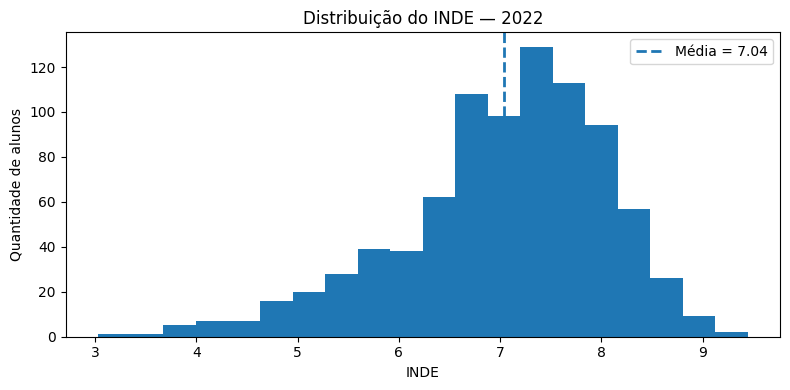

2022: 860 valores numéricos | 0 não utilizáveis no histograma


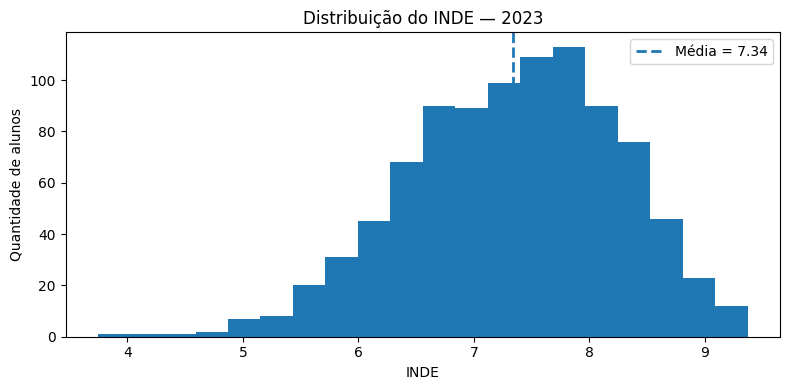

2023: 931 valores numéricos | 83 não utilizáveis no histograma


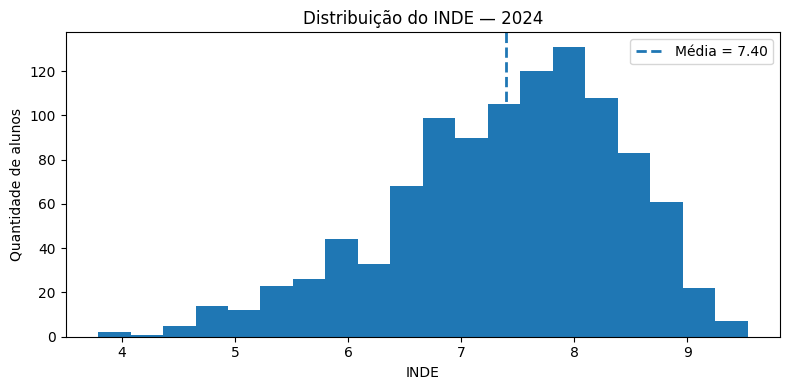

2024: 1054 valores numéricos | 102 não utilizáveis no histograma


In [18]:
for ano, df in {2022: df_2022, 2023: df_2023, 2024: df_2024}.items():
    coluna_inde = mapa_indicadores[ano]["INDE"]
    inde = pd.to_numeric(df[coluna_inde], errors="coerce")

    plt.figure(figsize=(8, 4))
    plt.hist(inde.dropna(), bins=20)
    plt.axvline(inde.mean(), linestyle="--", linewidth=2, label=f"Média = {inde.mean():.2f}")
    plt.title(f"Distribuição do INDE — {ano}")
    plt.xlabel("INDE")
    plt.ylabel("Quantidade de alunos")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"{ano}: {inde.notna().sum()} valores numéricos | {inde.isna().sum()} não utilizáveis no histograma")

## 11. Classificação por Pedra

A classificação por Pedra representa uma categorização do aluno a partir de seu INDE.

As categorias existentes são Quartzo, Ágata, Ametista e Topázio. A distribuição dessas classificações será analisada para verificar o perfil geral dos estudantes em cada período.

In [19]:
for ano, df in {2022: df_2022, 2023: df_2023, 2024: df_2024}.items():
    coluna_pedra = mapa_pedra[ano]
    print(f"\nPEDRA — {ano} ({coluna_pedra})")

    distribuicao = df[coluna_pedra].value_counts(dropna=False).to_frame("Quantidade")
    distribuicao["Percentual (%)"] = (distribuicao["Quantidade"] / len(df) * 100).round(2)
    display(distribuicao)


PEDRA — 2022 (Pedra 22)


,Quantidade,Percentual (%)
Pedra 22,,
Ametista,348,40.47
Ágata,250,29.07
Quartzo,132,15.35
Topázio,130,15.12



PEDRA — 2023 (Pedra 2023)


,Quantidade,Percentual (%)
Pedra 2023,,
Ametista,381,37.57
Agata,246,24.26
Topázio,232,22.88
NaN,83,8.19
Quartzo,72,7.10



PEDRA — 2024 (Pedra 2024)


,Quantidade,Percentual (%)
Pedra 2024,,
Ametista,391,33.82
Topázio,326,28.20
Agata,225,19.46
Quartzo,112,9.69
NaN,64,5.54
INCLUIR,38,3.29


## 12. Análise inicial da defasagem

A defasagem educacional é uma das principais variáveis de interesse do Datathon.

Além de ser utilizada na análise da adequação do aluno ao nível educacional, essa informação será investigada como possível base para a definição da variável-alvo do modelo preditivo.

Nesta etapa serão avaliados apenas sua disponibilidade, tipo, distribuição e possíveis inconsistências.

In [20]:
for ano, df in {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}.items():

    colunas_defasagem = [
        col for col in df.columns
        if "defas" in str(col).lower()
    ]

    print(f"{ano}: {colunas_defasagem}")

2022: ['Defas']
2023: ['Defasagem']
2024: ['Defasagem']


In [21]:
resumo_defasagem = []

for ano, df in {2022: df_2022, 2023: df_2023, 2024: df_2024}.items():
    coluna = mapa_defasagem[ano]
    s = pd.to_numeric(df[coluna], errors="coerce")

    print(f"\n{ano} — {coluna}")
    display(s.value_counts(dropna=False).sort_index().to_frame("Quantidade"))

    resumo_defasagem.append({
        "Ano": ano,
        "Média": round(s.mean(), 3),
        "Mínimo": s.min(),
        "Máximo": s.max(),
        "% negativos": round((s < 0).mean() * 100, 2),
        "% zero": round((s == 0).mean() * 100, 2),
        "% positivos": round((s > 0).mean() * 100, 2),
        "Nulos": s.isna().sum()
    })

display(pd.DataFrame(resumo_defasagem))


2022 — Defas


,Quantidade
Defas,
-5,1
-4,4
-3,23
-2,163
-1,410
0,247
1,9
2,3



2023 — Defasagem


,Quantidade
Defasagem,
-4,1
-3,13
-2,130
-1,408
0,420
1,37
2,5



2024 — Defasagem


,Quantidade
Defasagem,
-3,3
-2,90
-1,441
0,485
1,119
2,16
3,2


,Ano,Média,Mínimo,Máximo,% negativos,% zero,% positivos,Nulos
0,2022,-0.943,-5,2,69.88,28.72,1.40,0
1,2023,-0.655,-4,2,54.44,41.42,4.14,0
2,2024,-0.409,-3,3,46.19,41.96,11.85,0


## 13. Relações iniciais entre os indicadores

O desafio propõe investigar relações entre diferentes dimensões do desenvolvimento dos alunos, como engajamento, desempenho acadêmico, aspectos psicossociais, autoavaliação e ponto de virada.

Como exploração inicial, será calculada a correlação entre os indicadores numéricos disponíveis.

A correlação não será interpretada como relação causal, servindo apenas como ferramenta exploratória para identificar associações que mereçam investigação posterior.

In [22]:
dados_corr_2024 = {}
for indicador, coluna in mapa_indicadores[2024].items():
    if coluna is not None and coluna in df_2024.columns:
        dados_corr_2024[indicador] = pd.to_numeric(df_2024[coluna], errors="coerce")

df_indicadores_2024 = pd.DataFrame(dados_corr_2024)
correlacao_2024 = df_indicadores_2024.corr().round(2)
display(correlacao_2024)

,INDE,IAN,IDA,IEG,IAA,IPS,IPP,IPV
INDE,1.00,0.37,0.80,0.79,0.36,0.22,0.64,0.76
IAN,0.37,1.00,0.06,-0.19,0.02,0.07,0.15,0.19
IDA,0.80,0.06,1.00,0.54,0.22,0.01,0.40,0.51
IEG,0.79,-0.19,0.54,1.00,0.23,0.06,0.41,0.54
IAA,0.36,0.02,0.22,0.23,1.00,-0.01,0.11,0.15
IPS,0.22,0.07,0.01,0.06,-0.01,1.00,0.21,0.11
IPP,0.64,0.15,0.40,0.41,0.11,0.21,1.00,0.75
IPV,0.76,0.19,0.51,0.54,0.15,0.11,0.75,1.00


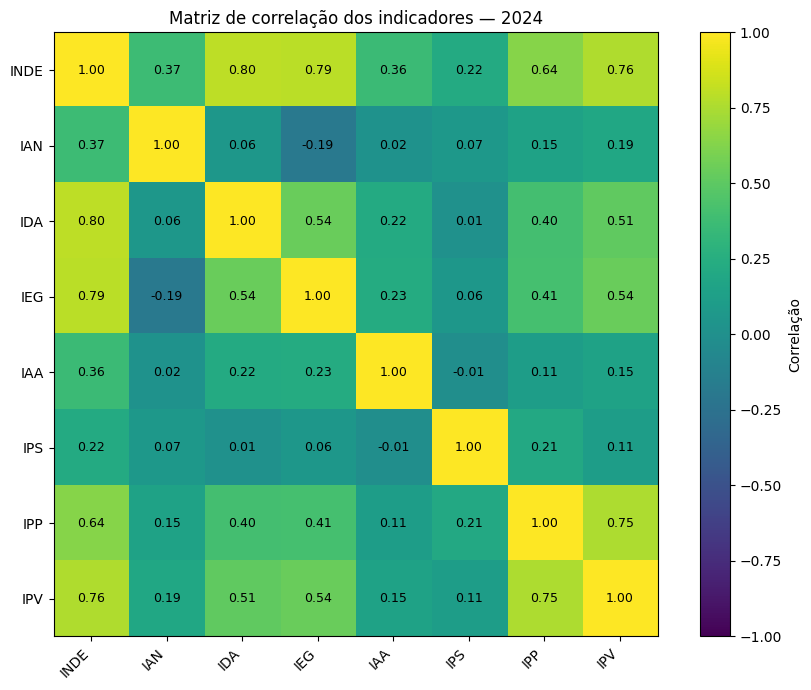

In [23]:

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(correlacao_2024.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacao_2024.columns)))
ax.set_yticks(range(len(correlacao_2024.index)))
ax.set_xticklabels(correlacao_2024.columns, rotation=45, ha="right")
ax.set_yticklabels(correlacao_2024.index)

for i in range(len(correlacao_2024.index)):
    for j in range(len(correlacao_2024.columns)):
        ax.text(j, i, f"{correlacao_2024.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Matriz de correlação dos indicadores — 2024")
fig.colorbar(im, ax=ax, label="Correlação")
plt.tight_layout()
plt.show()


### Leitura inicial das correlações de 2024

As maiores associações do INDE aparecem com **IDA (0,80)**, **IEG (0,79)** e **IPV (0,76)**. Também se destaca a correlação entre **IPP e IPV (0,75)**. Essas relações são exploratórias e não devem ser interpretadas como causalidade.

In [24]:
resumo = []

for ano, df in {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}.items():

    resumo.append({
        "Ano": ano,
        "Registros": len(df),
        "Colunas": df.shape[1],
        "Duplicados": df.duplicated().sum(),
        "Valores ausentes": df.isna().sum().sum(),
        "% células ausentes": round(
            df.isna().sum().sum() / df.size * 100,
            2
        ),
        "Colunas 100% nulas": int(df.isna().all().sum())
    })

df_resumo = pd.DataFrame(resumo)

display(df_resumo)

,Ano,Registros,Colunas,Duplicados,Valores ausentes,% células ausentes,Colunas 100% nulas
0,2022,860,42,0,2956,8.18,0
1,2023,1014,48,0,21157,43.47,16
2,2024,1156,50,0,21929,37.94,11


## 14. Conclusões da exploração inicial

A exploração confirmou que a base possui potencial para análises longitudinais e para a futura modelagem preditiva, mas exige padronização e correções antes das próximas etapas.

### Principais pontos identificados

- **Diferenças estruturais:** 2022 possui 860 registros e 42 colunas; 2023, 1.014 registros e 48 colunas; 2024, 1.156 registros e 50 colunas. Há diferenças de nomenclatura como `INDE 22`/`INDE 2023`/`INDE 2024`, `Defas`/`Defasagem` e `Matem`/`Mat`;
- **Valores ausentes:** 2022 possui 2.956 células ausentes (8,18%); 2023, 21.157 (43,47%); 2024, 21.929 (37,94%). Há 16 colunas 100% nulas em 2023 e 11 em 2024;
- **Inconsistências de tipos:** em 2023, `Idade` possui 615 inteiros e 399 valores interpretados como datas. Em 2024, `INDE 2024` possui 1.054 valores numéricos, 64 nulos e 38 registros com `INCLUIR`;
- **Duplicidades:** não há registros completamente duplicados;
- **Chave do aluno:** `RA` não possui nulos nem duplicados dentro de cada ano;
- **Acompanhamento longitudinal:** 600 alunos aparecem em 2022/2023, 765 em 2023/2024 e 468 estão presentes nos três anos;
- **Indicadores:** IAN, IDA, IEG, IAA, IPS e IPV estão disponíveis nos três anos. O IPP não existe em 2022. O INDE existe nos três anos, mas com nomes diferentes;
- **INDE:** médias aproximadas de 7,04 em 2022, 7,34 em 2023 e 7,40 em 2024. Isso ainda não permite concluir efetividade do programa, pois a composição da população e a completude dos dados variam;
- **Defasagem:** não possui nulos. A média passa de -0,943 em 2022 para -0,655 em 2023 e -0,409 em 2024; a proporção de valores negativos cai de 69,88% para 54,44% e 46,19%. O significado do sinal deverá ser validado antes de criar o target;
- **Correlações de 2024:** INDE apresenta correlação de 0,80 com IDA, 0,79 com IEG e 0,76 com IPV; IPP e IPV apresentam 0,75. São associações exploratórias, não relações causais.

### Próximos passos

No notebook `02_tratamento.ipynb` serão realizadas:

1. Padronização dos nomes das colunas;
2. Correção da idade de 2023;
3. Tratamento dos valores `INCLUIR` e demais inconsistências;
4. Avaliação e remoção justificada de colunas 100% nulas;
5. Padronização de categorias como `Ágata`/`Agata`;
6. Consolidação da base no formato longitudinal aluno-ano;
7. Validação de `Fase`, `Fase Ideal` e `Defasagem`;
8. Preparação das bases para análise, Power BI e Machine Learning;
9. Definição do target de risco com atenção a vazamento de informação.

> **Nota:** este notebook ainda não treina o modelo de Machine Learning. Os resultados acima são resultados reais da exploração da base e serão usados como fundamento das próximas etapas.